In [1]:
import os, sys, json

sys.path.append("../")
sys.path.append("../src/")
sys.path.append("../data/")
sys.path.append("../model_evaluation")
sys.path.append("../model_evaluation/evaluation")

In [2]:
with open("./t2t_eval_gpt.json", "r") as file:
    content = file.read()
    print(content)  # Debugging step
    t2t_gpt = json.loads(content)

with open("./m2m_eval_1_gpt.json", "r") as file:
    content = file.read()
    print(content)  # Debugging step
    m2m_1_gpt = json.loads(content)

with open("./m2m_eval_2_gpt.json", "r") as file:
    content = file.read()
    print(content)  # Debugging step
    m2m_2_gpt = json.loads(content)

{"X_g01.json": 0.7999999999999999, "R_g01.json": 0.73, "E_j01.json": 0.6633333333333334, "M_g01.json": 0.6333333333333333, "R_j04.json": 0.7566666666666667, "G_g01.json": 0.7399999999999999, "R_j03.json": 0.7566666666666667, "M_j02.json": 0.54, "V_k09.json": 0.7566666666666667, "V_k08.json": 0.7799999999999999, "M_j03.json": 0.7866666666666667, "R_j02.json": 0.7200000000000001, "R_j01.json": 0.7366666666666667, "E_j05.json": 0.4833333333333334, "G_j01.json": 0.6033333333333333, "M_k05.json": 0.6733333333333333, "E_j04.json": 0.5433333333333333, "M_j01.json": 0.6533333333333333, "V_g01.json": 0.7966666666666665, "M_g02.json": 0.7733333333333334, "E_j03.json": 0.4533333333333333, "E_j02.json": 0.6133333333333333, "G_g03.json": 0.58}
{"X_g01.json": 0.6652478771161001, "R_g01.json": 0.5150463445743169, "E_j01.json": 0.48849353827138114, "M_g01.json": 0.4884130166582956, "R_j04.json": 0.3725499577384705, "G_g01.json": 0.2959585281530953, "R_j03.json": 0.5212179602119554, "M_j02.json": 0.314

In [37]:
import json
import pandas as pd


gemini_data = pd.read_csv("../output_csv")
t2t, m2m_1, m2m_2 = gemini_data["t2t_eval"], gemini_data["m2m_eval_1"], gemini_data["m2m_eval_2"]

# data = pd.read_csv("../gpt_pett2t.csv")
# t2t_1, t2t_2, m2m_1, m2m_2 = (
#     data["t2t_eval_1"],
#     data["t2t_eval_2"],
#     data["m2m_eval_1"],
#     data["m2m_eval_2"],
# )
data = pd.read_csv("../gpt_real_setm2m.csv")
t2t_1, t2t_2, m2m_1, m2m_2 = (
    data["t2t_eval_1"],
    data["t2t_eval_2"],
    data["m2m_eval_1"],
    data["m2m_eval_2"],
)

In [38]:
t2t_1.values, t2t_2.values, m2m_1.values, m2m_2.values

(array([0.81333333, 0.73      , 0.74666667, 0.65      , 0.79      ,
        0.67      , 0.75666667, 0.53      , 0.83666667, 0.69333333,
        0.75666667, 0.70333333, 0.74      , 0.57333333, 0.64333333,
        0.66      , 0.66666667, 0.65666667, 0.85666667, 0.78      ,
        0.51666667, 0.61      , 0.64      ]),
 array([0.49208333, 0.37525163, 0.40190351, 0.325     , 0.41606149,
        0.335     , 0.42803377, 0.265     , 0.52410256, 0.35744755,
        0.37833333, 0.35166667, 0.42035651, 0.28666667, 0.32166667,
        0.33      , 0.34615385, 0.36718915, 0.46548611, 0.43583333,
        0.25833333, 0.305     , 0.34777778]),
 array([0.66784835, 0.47986663, 0.38631629, 0.46107569, 0.41289331,
        0.32596616, 0.55812027, 0.3614241 , 0.60988729, 0.85588638,
        0.49365197, 0.54697092, 0.72359607, 0.37831755, 0.5066574 ,
        0.46529179, 0.44106851, 0.43824002, 0.57120538, 0.59763246,
        0.33741601, 0.4239465 , 0.38622562]),
 array([0.59960562, 0.5202707 , 0.4245045 , 0.

/var/folders/nn/rsh9pz9s4mj886ccd7vnn0yc0000gn/T/ipykernel_4978/3024644955.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


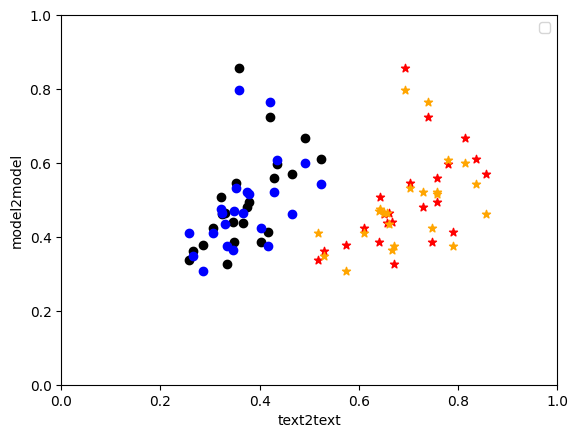

In [39]:
import matplotlib.pyplot as plt

plt.scatter(t2t_1.values, m2m_1.values, marker="*", color="red")
plt.scatter(t2t_1.values, m2m_2.values, marker="*", color="orange")
plt.scatter(t2t_2.values, m2m_1.values, marker="o", color="black")
plt.scatter(t2t_2.values, m2m_2.values, marker="o", color="blue")

plt.axis([0, 1, 0, 1])
plt.xlabel("text2text")
plt.ylabel("model2model")
plt.legend()

In [40]:
from scipy.stats import pearsonr, spearmanr

print(pearsonr(list(t2t_1.values), list(m2m_1.values)))
print(pearsonr(list(t2t_1.values), list(m2m_2.values)))
print(pearsonr(list(t2t_2.values), list(m2m_1.values)))
print(pearsonr(list(t2t_2.values), list(m2m_2.values)))

PearsonRResult(statistic=0.5479215504994704, pvalue=0.00679758717320501)
PearsonRResult(statistic=0.44288348668895117, pvalue=0.034309226878432006)
PearsonRResult(statistic=0.5688923782670594, pvalue=0.004614119687383875)
PearsonRResult(statistic=0.4707419406383745, pvalue=0.023385585843657814)


In [ ]:
with open("t2t_eval.json", "w") as outfile:
    json.dump(t2t_eval, outfile)
with open("m2m_eval_1.json", "w") as outfile:
    json.dump(m2m_eval_1, outfile)
with open("m2m_eval_2.json", "w") as outfile:
    json.dump(m2m_eval_2, outfile)

In [ ]:
from scipy.stats import pearsonr, spearmanr

pearsonr(list(t2t_eval.values()), list(m2m_eval_1.values())), spearmanr(
    list(t2t_eval.values()), list(m2m_eval_1.values())
)

In [ ]:
def remove_code_block_formatting(text):
    # Remove the triple backticks and the "json" tag
    if text.startswith("```json") and text.endswith("```"):
        print("y")
        text = text[7:-3]  # Remove the first 7 characters and last 3 characters
    return text.strip()

In [ ]:
text = model_2
if text.startswith("```json\n") and text.endswith("```\n"):
    print("y")
    print(text[7:-4])
# Remove the first 7 characters and last 3 characters

In [ ]:
import os
import json


def map_ids_in_bpmn(input_file_path):
    try:
        with open(input_file_path, "r") as file:
            data = json.load(file)

        id_counter = 1
        id_mapping = {}

        # Collect all unique IDs, including lanes
        all_elements = (
            data.get("tasks", [])
            + data.get("events", [])
            + data.get("gateways", [])
            + data.get("sequenceFlows", [])
            + data.get("messageFlows", [])
        )

        # Pools and Lane IDs
        for pool in data.get("pools", []):
            if "id" in pool:
                all_elements.append(pool)
            for lane in pool.get("lanes", []):
                all_elements.append(lane)

        # Map each unique ID to a sequential ID
        for element in all_elements:
            if element["id"] not in id_mapping:
                id_mapping[element["id"]] = f"id-{id_counter}"
                id_counter += 1

        # Replace old IDs with new sequential IDs
        def replace_ids(items):
            for item in items:
                if "id" in item:
                    item["id"] = id_mapping[item["id"]]
                if "targetRef" in item:
                    item["targetRef"] = id_mapping[item["targetRef"]]
                if "sourceRef" in item:
                    item["sourceRef"] = id_mapping[item["sourceRef"]]
                if "elemRefs" in item:
                    item["elemRefs"] = [id_mapping[ref] for ref in item["elemRefs"]]

        replace_ids(data.get("tasks", []))
        replace_ids(data.get("events", []))
        replace_ids(data.get("gateways", []))
        replace_ids(data.get("sequenceFlows", []))
        replace_ids(data.get("messageFlows", []))

        for pool in data.get("pools", []):
            if "id" in pool:
                pool["id"] = id_mapping[pool["id"]]
            if "lanes" in pool:
                replace_ids(pool["lanes"])
    except Exception as e:
        print(f"An error occurred: {e}")

    return data
    # # Write the modified data to the output file
    # with open(output_file_path, 'w') as output_file:
    #     json.dump(data, output_file, indent=4)

In [ ]:
path_model = "../data/real_set/bpmn-json-minimal/"
save_path = "../data/real_set/bpmn-minimal-json/"
for i in os.listdir(path_model):
    with open(path_model + i, "r") as infile:
        orig_model = json.load(infile)
        model = map_ids_in_bpmn(path_model + i)
        for j in list(bpmn_similarity.extract_bpmn_sets(orig_model).keys()):
            if bpmn_similarity.extract_bpmn_sets(model)[j] != bpmn_similarity.extract_bpmn_sets(orig_model)[j]:
                print(i)
            else:
                with open(save_path + i, "w") as output_file:
                    json.dump(model, output_file, indent=4)